In [1]:
!pip install torch
!pip install scikit-learn
!pip install onnx
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline


[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
    --------------------------------------- 0.3/15.8 MB ? eta -:--:--
   ----- ---------------------------------- 2.1/15.8 MB 7.3 MB/s eta 0:00:02
   -------- ------------------------------- 3.4/15.8 MB 7.5 MB/s eta 0:00:02
   --------- ------------------------------ 3.9/15.8 MB 5.6 MB/s eta 0:00:03
   --------------- ------------------------ 6.3/15.8 MB 6.9 MB/s eta 0:00:02
   ----------------- ---------------------- 6.8/15.8 MB 6.9 MB/s eta 0:00:02
   ------------------- -------------------- 7.9/15.8 MB 6.1 MB/s eta 0:00:02
   ------------------------ --------------- 9.7/15.8 MB 6.3 MB/s eta 0:00:01
   -------------------------- ------------- 10.5/15.8 MB 6.3 MB/s eta 0:00:01
   --------------------------- ------------ 10.7/15.8 MB 5.7 MB/s eta 0:00:01
   --------------------------- ------------ 10.7/15.8 MB 5.7 MB/s eta 0:00:01
   --------------------------------- ------ 13.1/15.8 MB 5.9 MB/s eta 0:00:01
   ------


[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [41]:
len(words)

32033

In [42]:
# 因为神经网络只能处理数字，因此要构建词典，将字符映射到数字上，为每个字符分配唯一的数字编号，并且可以相互转换
name_str = ''.join(words)
print(name_str)
unique_chars = set(name_str)
print(unique_chars)
list_chars = list(unique_chars)
print(list_chars)
chars = sorted(list_chars)  # 把所有名字拼成一个长字符串
print(chars)
print(len(chars))
# 构建字符到整数的映射，这里的映射是从 1 开始的，因为要将 0 保留为映射到 .
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
print(stoi.items())
# 反向映射，把整数映射回字符，方便后续把模型输出的数字还原为字符
itos = {i:s for s,i in stoi.items()}
print(itos)

...
{'a', 'u', 'l', 'c', 'f', 'g', 'r', 'h', 's', 'o', 'p', 'x', 'e', 't', 'j', 'm', 'i', 'w', 'k', 'd', 'y', 'b', 'z', 'n', 'v', 'q'}
['a', 'u', 'l', 'c', 'f', 'g', 'r', 'h', 's', 'o', 'p', 'x', 'e', 't', 'j', 'm', 'i', 'w', 'k', 'd', 'y', 'b', 'z', 'n', 'v', 'q']
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
26
dict_items([('a', 1), ('b', 2), ('c', 3), ('d', 4), ('e', 5), ('f', 6), ('g', 7), ('h', 8), ('i', 9), ('j', 10), ('k', 11), ('l', 12), ('m', 13), ('n', 14), ('o', 15), ('p', 16), ('q', 17), ('r', 18), ('s', 19), ('t', 20), ('u', 21), ('v', 22), ('w', 23), ('x', 24), ('y', 25), ('z', 26), ('.', 0)])
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


构建训练数据集，train/dev/test 数据分别占总数据量的 80/10/10
- 训练集：用于模型的学习过程，模型通过训练集中的数据不断调整参数（例如神经网络的权重），最小化 loss
- 验证集：用于模型的调优过程，在训练过程中，模型并不会用验证集来更新参数，而是用来评估模型在未见过的数据上的表现。
  - 用于超参数调整，例如学习率、网络层数、正则化系数
  - 用于早停，防止过拟合：如果模型在训练集上的表现越来越好，但是在验证集上表现变差，说明模型开始记忆训练数据而不是泛化规律
- 测试集：在模型的训练和调优都完成后，才使用测试集来评估模型的泛化能力（在未见过的数据上的表现）
  - 用于模型的最终评估，测试集在整个开发过程中都不能被用来训练或调优模型

In [44]:
# 将名字列表转化为神经网络训练用的输入输出对，每个输入是前三个字符（上下文），目标输出是下一个字符
block_size = 3 # 设置上下文长度
def build_dataset(words):
  X, Y = [], []
  for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(n1, n2 - n1, len(words) - n2)
print(Xte.shape, Yte.shape)
for idx in range(10):
    print(Xte[idx], Yte[idx])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])
25626 3203 3204
torch.Size([22799, 3]) torch.Size([22799])
tensor([0, 0, 0]) tensor(13)
tensor([ 0,  0, 13]) tensor(5)
tensor([ 0, 13,  5]) tensor(12)
tensor([13,  5, 12]) tensor(5)
tensor([ 5, 12,  5]) tensor(1)
tensor([12,  5,  1]) tensor(0)
tensor([0, 0, 0]) tensor(1)
tensor([0, 0, 1]) tensor(12)
tensor([ 0,  1, 12]) tensor(15)
tensor([ 1, 12, 15]) tensor(14)


In [45]:
# 初始化神经网络的参数，
# 每个字符都被映射为一个 10 维的向量（嵌入层/embedding layer）
# 模型 W1 的权重为（30，200），30 是 3 * 10，即上下文的长度乘以嵌入向量的维度，200 是隐藏层的神经元个数
# 模型 W2 的权重为（200, 27），200 是隐藏层神经元数量，27 是输出类别数，即预测下一个字符
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [12]:
import torch
import torch.nn as nn
import torch.onnx

# 第一步：定义模型类，继承 nn.Module
class CharMLP(nn.Module):
    def __init__(self, vocab_size=27, emb_dim=10, context_size=3, hidden_size=200):
        super(CharMLP, self).__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)  # 嵌入层，替换 C
        self.fc1 = nn.Linear(context_size * emb_dim, hidden_size)  # 隐藏层，替换 W1/b1
        self.fc2 = nn.Linear(hidden_size, vocab_size)  # 输出层，替换 W2/b2

    def forward(self, x):
        emb = self.embedding(x)  # [batch, context_size] -> [batch, context_size, emb_dim]
        emb_flat = emb.view(emb.size(0), -1)  # 展平为 [batch, context_size * emb_dim]
        h = torch.tanh(self.fc1(emb_flat))  # 隐藏层 + tanh
        logits = self.fc2(h)  # 输出 logits [batch, vocab_size]
        return logits

# 第二步：实例化模型，并加载现有参数（假设 C, W1, b1, W2, b2 已定义并训练）
model = CharMLP()

# 加载参数（需匹配现有张量，并转置权重以匹配 nn.Linear 的期望形状）
model.embedding.weight.data = C  # C 是 (27,10)，直接匹配
model.fc1.weight.data = W1.t()   # W1 是 (30,200)，转置为 (200,30)
model.fc1.bias.data = b1        # b1 是 (200)
model.fc2.weight.data = W2.t()   # W2 是 (200,27)，转置为 (27,200)
model.fc2.bias.data = b2        # b2 是 (27)

# 设置为评估模式（可选，但推荐）
model.eval()

# 第三步：准备 dummy 输入（示例：batch_size=1, context_size=3）
dummy_input = torch.tensor([[0, 0, 0]], dtype=torch.long)  # 示例上下文，shape [1, 3]

# 第四步：导出为 ONNX
torch.onnx.export(
    model,                  # 模型实例
    dummy_input,            # 示例输入
    "mlp_model.onnx",       # 输出文件名
    verbose=True,           # 打印详细信息
    input_names=['input'],  # 输入节点名
    output_names=['output'],# 输出节点名
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}  # 支持动态 batch
)

print("模型已导出为 mlp_model.onnx")

模型已导出为 mlp_model.onnx


In [46]:
total_params = sum(p.numel() for p in parameters)
print("Total number of parameters:", total_params)

Total number of parameters: 11897


In [47]:
# 设置在计算过程中保存参数的梯度信息
for p in parameters:
    p.requires_grad = True

In [48]:
# 生成一组在对数空间均匀分布的学习率，通常用于学习率搜索或可视化
# lre 是学习率的指数
lre = torch.linspace(-3, 0, 1000) # 生成总共 1000 个x值，从 -3 到 0，均匀分布
print(len(lre))
# print(lre)
# 生产
# 对 lre 中的每个元素计算指数，获取从 0.001 到 1.0 之间的 1000 个学习率值，且在对数空间均匀分布
# 这种方式可以让我们在很宽的范围内以对数刻度尝试不同的学习率
lrs = 10**lre
print(lrs)

1000
tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0

In [49]:
lri = []
lossi = []
stepi = []

In [34]:
  # minibatch construct
  # 从训练数据中采样 32 个样本的索引，形成一个 batch
  # 每一个样本是 3 个 context 字符和一个预测字符 y
  ix = torch.randint(0, Xtr.shape[0], (32,))
  print(len(ix))
  print(len(Xtr[ix]))
  #   print(Xtr[ix])

  # forward pass
  # 获取词嵌入向量，每个词都由 10 维向量表示，这里提取出了 minibatch 里 32 个词的数字表达
  # 词嵌入表本身也参与了训练过程，并且能自动学习词到词之间的关系，比如相似的词向量距离更近
  # 这里与先前的试验不同，如果我们用onehot来表达，那么需要用 27 维的向量表示，并且不能学习字符之间的关系
  emb = C[Xtr[ix]]
  print(emb.shape)
  #print(emb)
  #print(emb.view(-1, 30))
  print(emb.view(-1, 30).shape)

  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  print(h.shape)
  logits = h @ W2 + b2  # (32, 27)
  print(logits.shape)

32
32
torch.Size([32, 3, 10])
torch.Size([32, 30])
torch.Size([32, 200])
torch.Size([32, 27])


In [52]:
for i in range(200000):
  
  # minibatch construct
  # 从训练数据中采样 32 个样本的索引，形成一个 batch
  # 每一个样本是 3 个 context 字符和一个预测字符 y
  ix = torch.randint(0, Xtr.shape[0], (32,))
  # print(len(Xtr))

  # forward pass
  # 获取词嵌入向量，每个词都由 10 维向量表示，这里提取出了 minibatch 里 32 个词的数字表达
  # 词嵌入表本身也参与了训练过程，并且能自动学习词到词之间的关系，比如相似的词向量距离更近
  # 这里与先前的试验不同，如果我们用onehot来表达，那么需要用 27 维的向量表示，并且不能学习字符之间的关系
  emb = C[Xtr[ix]]

  # print(emb)
  # print(emb.shape)

  # print(emb.view(-1, 30))
  # print(emb.view(-1, 30).shape)

  # 把每个样本的 3 个字符拼接成一个 30 维的向量
  # 通过 W1+b1 连接到隐藏层，W1(30, 200), b1(200)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  # W2 (200,27), b2(27)，结果为(32, 27)，32 come from 32 samples
  logits = h @ W2 + b2
  # 计算模型输出和目标标签之间的交叉熵损失
  loss = F.cross_entropy(logits, Ytr[ix])
  print("step:", i, "loss:", loss.item())
  
  # backward pass
  # 先将所有参数的梯度清零，防止累加，然后计算每个参数的梯度
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # 根据训练的进度来更新学习率
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track 当前步数和损失的对数值，便于后续画图分析训练过程
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

print(loss.item())

step: 0 loss: 3.0206449031829834
step: 1 loss: 4.07476806640625
step: 2 loss: 2.43904972076416
step: 3 loss: 2.528010129928589
step: 4 loss: 3.5940306186676025
step: 5 loss: 3.4375698566436768
step: 6 loss: 3.490842580795288
step: 7 loss: 2.408501625061035
step: 8 loss: 3.0967676639556885
step: 9 loss: 2.514939785003662
step: 10 loss: 3.115509271621704
step: 11 loss: 3.7039265632629395
step: 12 loss: 2.746061325073242
step: 13 loss: 2.6328608989715576
step: 14 loss: 2.8284130096435547
step: 15 loss: 3.911618709564209
step: 16 loss: 2.8874638080596924
step: 17 loss: 3.3407719135284424
step: 18 loss: 3.3784804344177246
step: 19 loss: 3.0988545417785645
step: 20 loss: 2.46547794342041
step: 21 loss: 2.394890069961548
step: 22 loss: 3.3120229244232178
step: 23 loss: 3.4824538230895996
step: 24 loss: 3.1785295009613037
step: 25 loss: 2.8132219314575195
step: 26 loss: 2.805870771408081
step: 27 loss: 2.571810722351074
step: 28 loss: 3.2588107585906982
step: 29 loss: 3.1820006370544434
step: 

KeyboardInterrupt: 

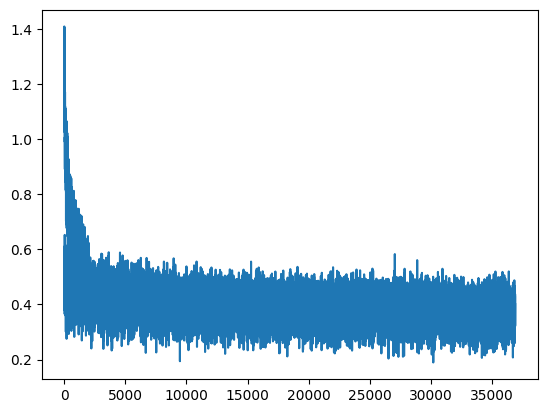

In [53]:
# 打印出随着训练次数的增加，loss 的变化趋势
plt.plot(stepi, lossi)

In [67]:
# training loss 
emb = C[Xtr] # (32, 3, 2)
print(emb.shape)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

torch.Size([182580, 3, 10])


tensor(2.3660, grad_fn=<NllLossBackward0>)

In [70]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
print(emb.shape)
print(emb.view(-1, 30).shape)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

torch.Size([22767, 3, 10])
torch.Size([22767, 30])


tensor(2.3831, grad_fn=<NllLossBackward0>)

In [73]:
# test loss
emb = C[Xte] # (32, 3, 2)
print(emb.shape)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
# cross entropy 默认会对所有样本的损失取平均，反映了模型在整个测试集上的整体表现
print(logits.shape)
# print(logits[0])

print(Yte.shape)
# print(Yte[0])
loss = F.cross_entropy(logits, Yte)
loss

torch.Size([22799, 3, 10])
torch.Size([22799, 27])
torch.Size([22799])


tensor(2.3966, grad_fn=<NllLossBackward0>)

交叉熵损失函数的功能是衡量模型输出概率分布与真实标签之间的差异，是分类任务中最常用的损失函数。
输入：logits 模型输出的未归一化的分
输出：Yte 每个样本的真实类别标签
过程：
1. 对 logits 做 softmax，得到每个类别的概率分布
2. 取出每个样本真实类别对应的概率
3. 取出对数并取负号，得到每个样本的损失
4. 对所有样本的损失取平均（默认）

这样的的意义是：
- 如果模型输出的概率分布在真实类别上，损失就小
- 如果模型输出的分布和真实标签差异大，损失就大

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.8 kB 220.2 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 324.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.7 MB 1.7 MB/s eta 0:00:06
   ---------------------------------------- 0.1/8.7 MB 787.7 kB/s eta 0:00:11
    --------------------------------------- 0.1/8.7 MB 939.4 kB/s eta 0:00:10
    --------------------------------------- 0.1/8.7 MB 602.4 kB/s eta 0:00:15
    --------------------------------------- 0.2/8.7 MB 612.6 kB/s eta 0:00:15
   - -------------------


[notice] A new release of pip is available: 24.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


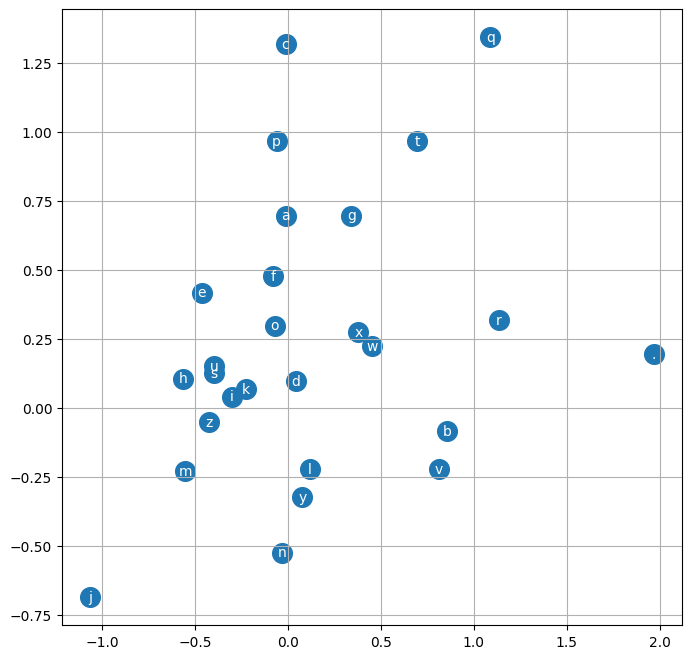

In [16]:
# 可视化嵌入矩阵的字符表达的 dimensions 0 and 1
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

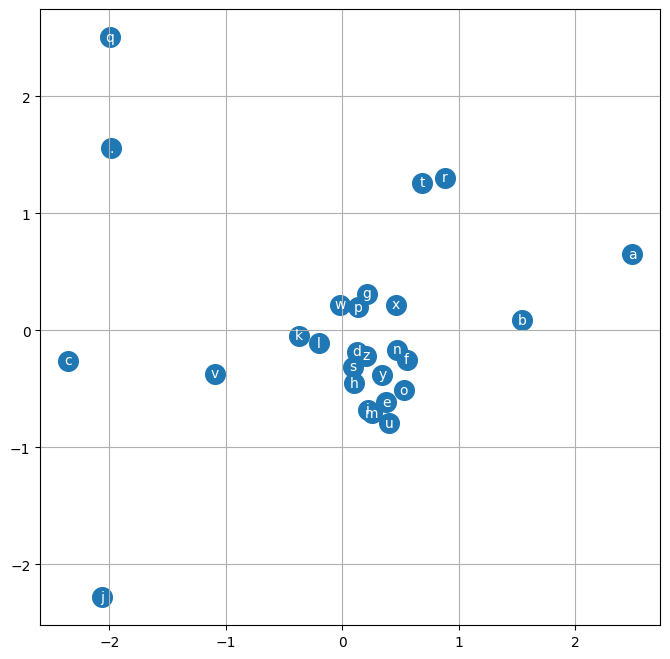

In [22]:
# 2-dimen 矩阵不能很好地展示高维数据之间的关系，
# PCA 可以把高维数据投影到方差最大的两个方向上，尽量保留原始数据的主要结构，
# 这样二维图能更好地反映高维空间的主要分布
from sklearn.decomposition import PCA

# C 是 (27, 10) 的嵌入矩阵
pca = PCA(n_components=2)
C_2d = pca.fit_transform(C.data.numpy())

plt.figure(figsize=(8,8))
plt.scatter(C_2d[:,0], C_2d[:,1], s=200)
for i in range(C_2d.shape[0]):
    plt.text(C_2d[i,0], C_2d[i,1], itos[i], ha="center", va="center", color='white')
plt.grid('minor')
plt.show()

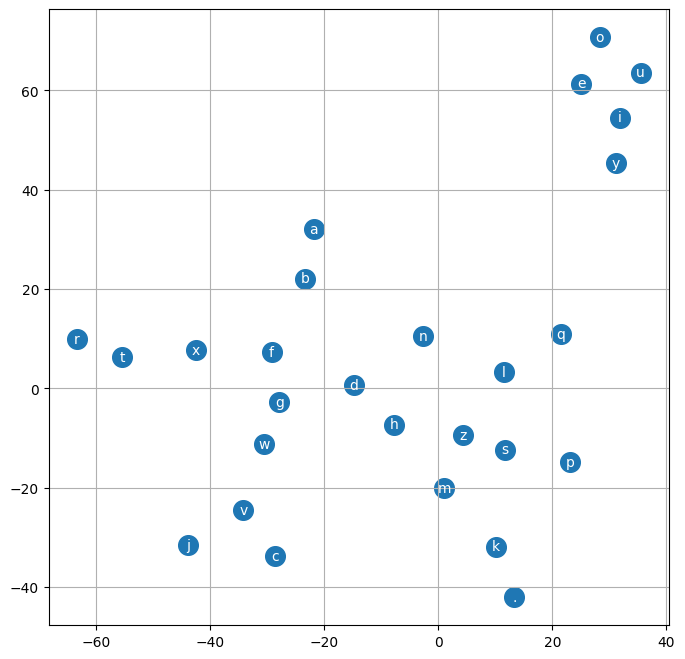

In [23]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 假设 C 是 PyTorch tensor，itos 是编号到字符的映射
C_np = C.detach().cpu().numpy()  # 转为 numpy 数组
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
C_2d = tsne.fit_transform(C_np)

plt.figure(figsize=(8,8))
plt.scatter(C_2d[:,0], C_2d[:,1], s=200)
for i in range(C_2d.shape[0]):
    plt.text(C_2d[i,0], C_2d[i,1], itos[i], ha="center", va="center", color='white')
plt.grid('minor')
plt.show()

In [66]:
# 最后用训练好的模型来采样数据，推理生成一些名字
g = torch.Generator().manual_seed(2147483648 + 4)

for _ in range(20):
    out = []
    # context = [0] * block_size # initialize with all ...
    context = [0] + [1] + [2] # initialize with all ...

    # 不断生成下一个字符，直到遇到终止符 "." 为止
    while True:
      # 使用当前 context 查表获得嵌入向量，
      emb = C[torch.tensor([context])] # (1,block_size,d)
      print(emb.shape)
    #   print(emb.shape)
      print(emb.view(1, -1).shape)
      # 把嵌入向量展平为一维，然后输入到隐藏层
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      # 隐藏层通过全连接层映射到 27 个类别
      logits = h @ W2 + b2
      print(logits.shape)
      print(logits)
      # 通过 softmax 得到每个字符的概率分布
      probs = F.softmax(logits, dim=1)
      print(probs.shape)
      print(probs)
      # 按概率分布随机采样一个字符编号（不总是选择最大概率），这样生成的名字更有多样性
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # 更新上下文窗口：滑动窗口，去掉最左边，加上新生成的字符编号
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    # 将编号序列 out 转换成字符，拼接成字符串，打印出来
    print(''.join(itos[i] for i in out))


torch.Size([1, 3, 10])
torch.Size([1, 30])
torch.Size([1, 27])
tensor([[ -1.6956,   3.3871,   1.8017,  -5.3953,   4.5843,   2.4759, -11.0372,
          -2.0080,   2.3583,   2.7816,  -2.8591,  -3.3769,   1.3809,  -3.4571,
          -0.7187,   1.9738,  -3.9751,  -7.2251,   2.6229,  -0.0780,   0.2141,
           2.5382,   1.5959,  -0.9002,  -4.6392,   1.7532,  -4.5252]],
       grad_fn=<AddBackward0>)
torch.Size([1, 27])
tensor([[8.1902e-04, 1.3203e-01, 2.7049e-02, 2.0255e-05, 4.3711e-01, 5.3081e-02,
         7.1828e-08, 5.9928e-04, 4.7194e-02, 7.2065e-02, 2.5585e-04, 1.5244e-04,
         1.7758e-02, 1.4069e-04, 2.1755e-03, 3.2129e-02, 8.3813e-05, 3.2497e-06,
         6.1487e-02, 4.1285e-03, 5.5289e-03, 5.6496e-02, 2.2017e-02, 1.8144e-03,
         4.3140e-05, 2.5767e-02, 4.8349e-05]], grad_fn=<SoftmaxBackward0>)
torch.Size([1, 3, 10])
torch.Size([1, 30])
torch.Size([1, 27])
tensor([[  8.6004,  10.8674,   5.4127,  -4.3047,   3.2192,   9.9406,  -8.5456,
          -0.3196,   2.7072,  10.8334